## Heart Disease 



### Objective
* predict whether a patient has heart disease.
* Binary classification

### Why heart disease dataset ?
* Fast training on tabular dataset
* Intutive to explain features (medical measurements)
* Parameters, Gradient descent, Optimizers, hyperparameter tuning , fine tuning can be demonstrated

#### Load Data

In [49]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('heart_disease_uci.csv')
df.head(1)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0


#### Check number of uniques values and number of null values in different columns

In [94]:

for cols in ['sex','dataset','cp','fbs','restecg','slope','thal']:
    print(df[cols].unique())
print(df.isnull().sum())


[1 0]
[0 1 2 3]
[3 0 2 1]
[1 0]
[0 1 2]
[0 1 3 2]
[0 2 3 1]
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs           0
restecg       0
thalch       55
exang         0
oldpeak      62
slope         0
ca          611
thal          0
num           0
dtype: int64


#### Handeling Missing Values

In [111]:
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    med = df[col].median()
    df[col].fillna(med)  
    print(f"{col} ", df[col].isna().sum())
# df = df.drop('ca', axis=1)
print(df.head(2))



trestbps  0
chol  0
thalch  0
oldpeak  0
   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   

   oldpeak  slope  thal  num  
0      2.3      0     0    0  
1      1.5      1     2    2  


In [112]:
for cat_cols in ['fbs','exang','restecg']:
    mod= df[cat_cols].mode()[0]
    df[cat_cols]=df[cat_cols].fillna(mod).astype('object')
    print(df[cat_cols].isna().sum())
df['slope']=df['slope'].fillna('missing')
df['thal']=df['thal'].fillna('missing')
print(df['slope'].isna().sum())
print(df['thal'].isna().sum())

cat_cols_all=['fbs','exang','restecg','slope','thal']



0
0
0
0
0


#### Visualization of data using different plots


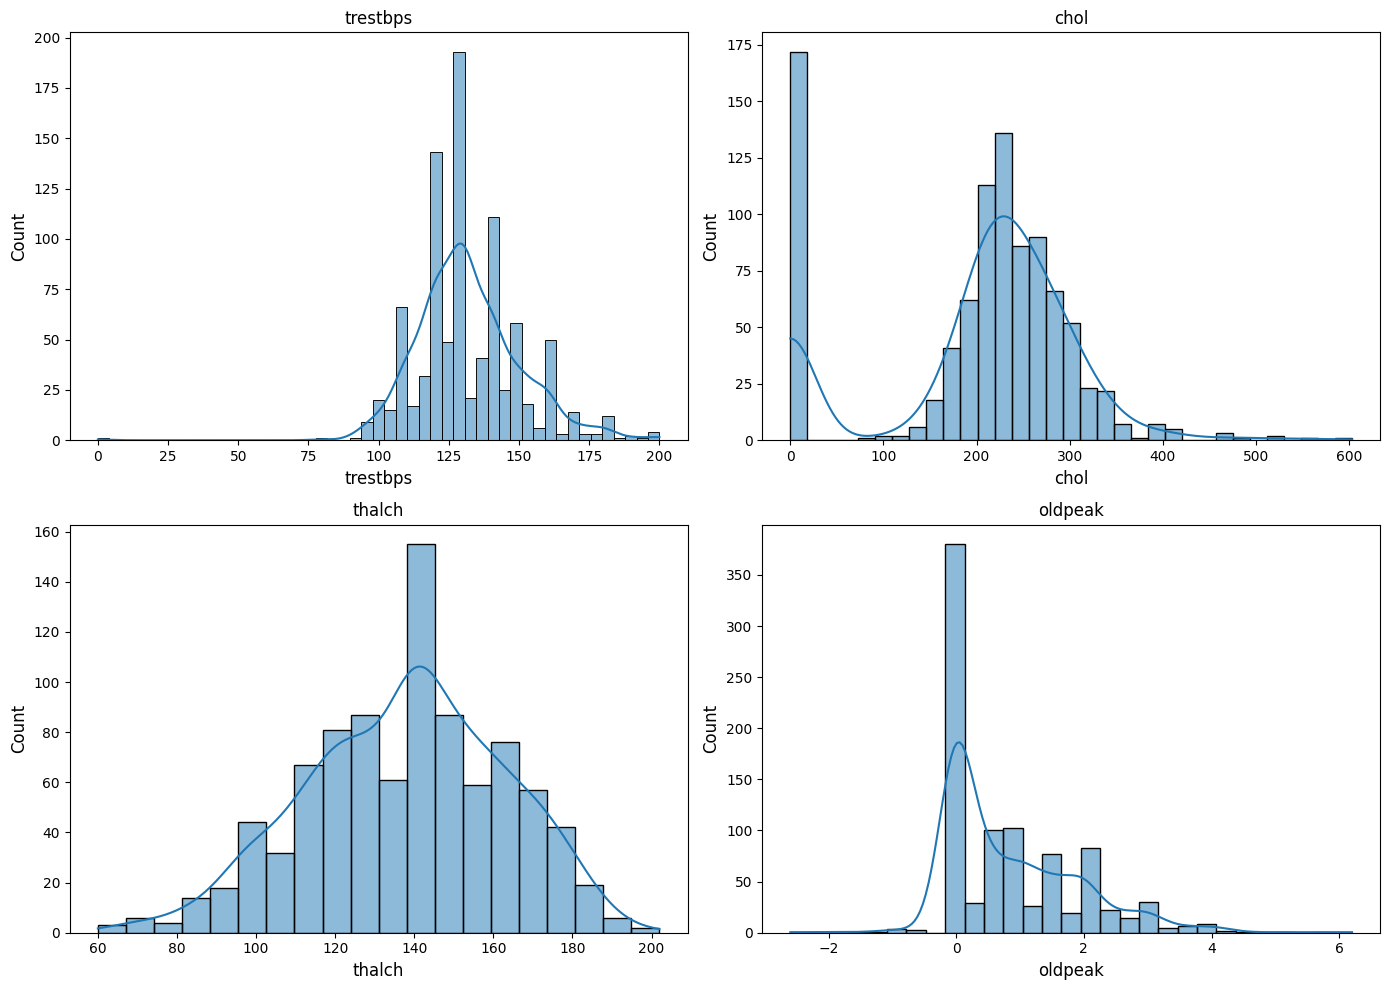

In [113]:
fig, axes = plt.subplots(nrows = 2, ncols=2, figsize=(14,10))
axes = axes.flatten()
for i, cols in enumerate(['trestbps', 'chol', 'thalch', 'oldpeak']):
    sns.histplot(df[cols], kde=True, ax = axes[i])
    axes[i].set_title(cols,fontsize=12)
    axes[i].set_xlabel(cols, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     920 non-null    object 
 13  ca        309 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


#### Categorical columns converted into numerical column

In [114]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)
# df_modi = df.copy()  
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes



Categorical columns: ['fbs', 'restecg', 'exang']


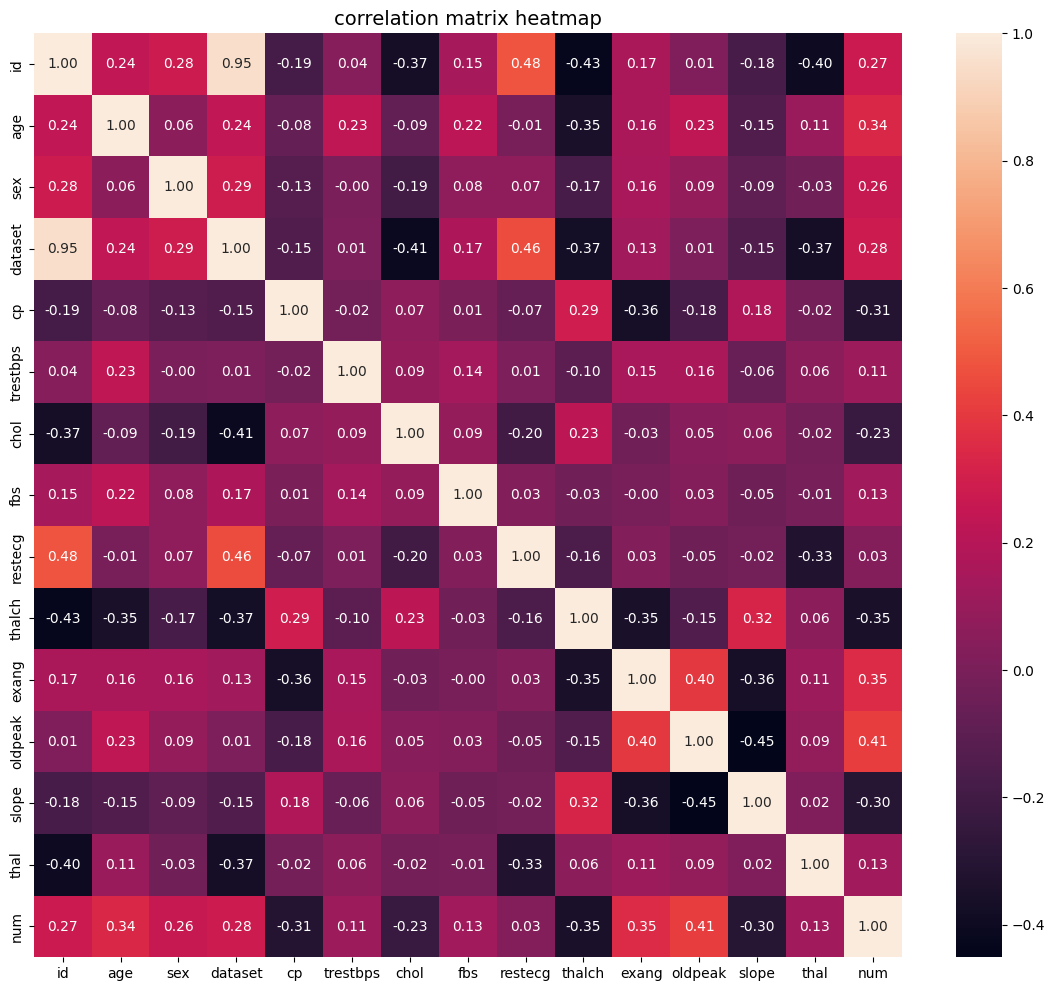

In [115]:
corr_mat = df.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_mat, annot=True, fmt=".2f",cbar=True)
plt.title("correlation matrix heatmap",fontsize=14)
plt.show()

* It is seen that oldpeak, ca, age, exang carry high correlation with output. so these can be considered predictors for modelling

* since id and dataset may not be useful so they can be dropped

#### Train-Test Split
* Features X and y
* Dataset split
* Numerical features are scaled

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('num', axis=1)
y = df['num']
# df.columns
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

scaler = StandardScaler()
num_cols_total = ["age","trestbps","chol","thalch","oldpeak"]
X_train[num_cols_total] = scaler.fit_transform(X_train[num_cols_total])
X_test[num_cols_total] = scaler.transform(X_test[num_cols_total])


#### Train a baseline model

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logistic = LogisticRegression(max_iter=100, random_state=42)

logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred,average='macro'))
print("Recall:", recall_score(y_test, y_pred,average='macro'))
print("F1 Score:", f1_score(y_test, y_pred,average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, logistic.predict_proba(X_test), multi_class='ovr'))

Accuracy: 0.5543478260869565
Precision: 0.32150169855695243
Recall: 0.3270883190883191
F1 Score: 0.30892546151166844
ROC-AUC: 0.7984852101560896


d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [123]:
# defining parameter distribution for both grid and randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear','saga']
}


param_dist = {
    'C': np.logspace(-2,2,20),
    'penalty': ['l1','l2'],
    'solver': ['liblinear','saga']
}

In [128]:
# Grid Search
grid_search = GridSearchCV(
    logistic,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

logi_grid_best = grid_search.best_estimator_
y_pred_grid = logi_grid_best.predict(X_test)

Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.34747506130044536


d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [129]:
#Randomized search
random_search = RandomizedSearchCV(
    logistic,
    param_distributions=param_dist,
    n_iter=20,  
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

logi_random_best = random_search.best_estimator_
y_pred_random = logi_random_best.predict(X_test)


Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(37.92690190732246)}
Best CV Score: 0.3475357803309615


d:\AMNIL-Internship\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [130]:
# Comparison of randomized search and grid search 
results = {
    "Method": ["Grid Search", "Randomized Search"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_random)
    ],
    "F1 Macro": [
        f1_score(y_test, y_pred_grid, average='macro'),
        f1_score(y_test, y_pred_random, average='macro')
    ]
}

results_df = pd.DataFrame(results)
print(results_df)


              Method  Accuracy  F1 Macro
0        Grid Search  0.527174  0.294348
1  Randomized Search  0.527174  0.294348


### Using pytorch

In [131]:
df_pytorch = df.copy()

In [132]:
# feature and target separation
X_py = df_pytorch.drop('num',axis=1).values
y_py = df_pytorch['num'].values

In [137]:
# train test split
import torch
import torch.nn as nn

X_train, X_test, y_train, y_test = train_test_split(
    X_py, y_py, test_size=0.2, random_state=42
)

# Conversion to pytorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [161]:

# Defining logistic regression
num_features = X_train.shape[1]
num_class = len(set(y_train))

model = nn.Linear(num_features,num_class)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)





In [162]:
# Training loop
for epoch in range(400):  # fewer epochs for simplicity
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 50, Loss: 10.3370
Epoch 100, Loss: 2.2134
Epoch 150, Loss: 1.3035
Epoch 200, Loss: 1.0128
Epoch 250, Loss: 0.9811
Epoch 300, Loss: 0.9673
Epoch 350, Loss: 0.9583
Epoch 400, Loss: 0.9517


In [163]:
outputs = model(X_test_tensor)
_, pred = torch.max(outputs,1)
print("Test Accuracy:", accuracy_score(y_test, pred))
print("Test F1 Macro:", f1_score(y_test, pred, average='macro'))


Test Accuracy: 0.5543478260869565
Test F1 Macro: 0.32377840024898846
